In [1]:
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'DWH').exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from DWH.connection.connect import get_engine, getData

In [2]:
engine = get_engine()

## Reeks 1 - 1

In [ ]:
query_dimStaff = """SELECT * from dimStaff"""
query_dimDepartement = """SELECT * from dimDepartement"""
query_factStaffCommute = """SELECT * from factStaffCommute"""

In [ ]:
df_dimStaff = getData(engine=engine, query=query_dimStaff)
df_dimDepartement = getData(engine=engine, query=query_dimDepartement)
df_factStaffCommute = getData(engine=engine, query=query_factStaffCommute)

In [ ]:
print(df_dimStaff.head(3))
print(df_dimDepartement.head(3))
print(df_factStaffCommute.head(3))

   StaffKey StaffID                Campus  DepartementKey
0         1       1          Campus Aalst             1.0
1         2       2  Campus Schoonmeersen             1.0
2         3       3  Campus Schoonmeersen             1.0
   DepartementKey DepartementName StartDate EndDate
0               1             ALG      None    None
1               2              CA      None    None
2               3             DBH      None    None
   StaffCommuteKey  StaffKey   DateKey  Period  DistanceKM
0                1         2  20250401  apr/25         7.6
1                2         2  20250401  apr/25         7.6
2                3         2  20250701  jul/25         7.6


In [ ]:
df = pd.merge(df_dimStaff,right=df_dimDepartement,on="DepartementKey")

In [ ]:
df = df.merge(right=df_factStaffCommute, on="StaffKey")

In [ ]:
df.head(3)

,StaffKey,StaffID,Campus,DepartementKey,DepartementName,StartDate,EndDate,StaffCommuteKey,DateKey,Period,DistanceKM
0,1,1,Campus Aalst,1.0,ALG,None,None,4509,20250403,apr/25,30.0
1,1,1,Campus Aalst,1.0,ALG,None,None,4510,20251203,dec/25,30.0
2,1,1,Campus Aalst,1.0,ALG,None,None,10212,20240905,sep/24,30.0


In [ ]:
df['Year'] = df['DateKey'].astype(str).str[:4]

In [ ]:
df.head(3)

,StaffKey,StaffID,Campus,DepartementKey,DepartementName,StartDate,EndDate,StaffCommuteKey,DateKey,Period,DistanceKM,Year
0,1,1,Campus Aalst,1.0,ALG,None,None,4509,20250403,apr/25,30.0,2025
1,1,1,Campus Aalst,1.0,ALG,None,None,4510,20251203,dec/25,30.0,2025
2,1,1,Campus Aalst,1.0,ALG,None,None,10212,20240905,sep/24,30.0,2024


In [ ]:
staff_jaar_totalen = df.groupby(['StaffKey', 'DepartementName', 'Year'])['DistanceKM'].sum().reset_index()

In [ ]:
stats = staff_jaar_totalen.groupby(['DepartementName', 'Year']).agg(
    totaal_km=('DistanceKM', 'sum'),
    aantal_staff=('StaffKey', 'nunique')
).reset_index()

In [ ]:
stats['avg_per_werknemer'] = stats['totaal_km'] / stats['aantal_staff']

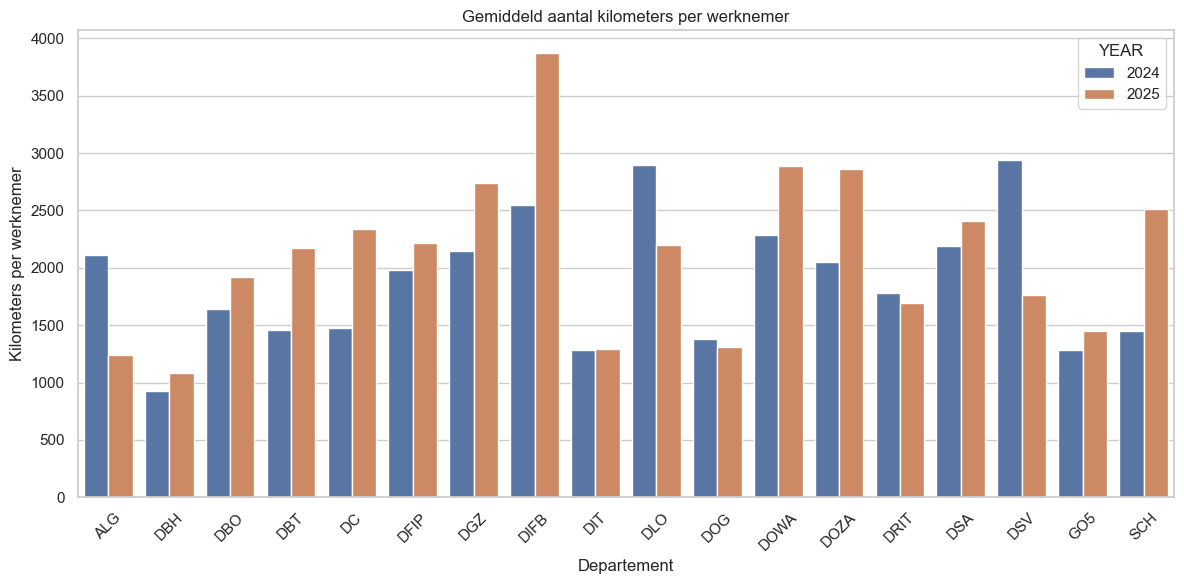

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=stats, 
    x='DepartementName', 
    y='avg_per_werknemer', 
    hue='Year', 
    order=stats['DepartementName'],
)

# Styling
plt.title('Gemiddeld aantal kilometers per werknemer')
plt.xlabel('Departement')
plt.ylabel('Kilometers per werknemer')
plt.legend(title='YEAR')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Reeks 1 - 2

In [ ]:
query = """
    select dd.dutchDayNameOfWeek, avg(totalcounts) as avgBikers 
    from FactCountings fc
    join DimDate dd on dd.DateKey = fc.DateKey
    group by dd.dutchDayNameOfWeek
"""


In [ ]:
df = getData(engine=engine, query=query)
df.head()

,dutchDayNameOfWeek,avgBikers
0,donderdag,881
1,dinsdag,904
2,zondag,639
3,maandag,830
4,woensdag,898


#### order de dates van maandag &rarr; zondag

In [ ]:
ordered = ['maandag', 'dinsdag', 'woensdag', 'donderdag', 'vrijdag', 'zaterdag', 'zondag']
df['dutchDayNameOfWeek'] = pd.Categorical(df['dutchDayNameOfWeek'], categories=ordered, ordered=True)
df = df.sort_values('dutchDayNameOfWeek')
df

,dutchDayNameOfWeek,avgBikers
3,maandag,830
1,dinsdag,904
4,woensdag,898
0,donderdag,881
6,vrijdag,834
5,zaterdag,647
2,zondag,639


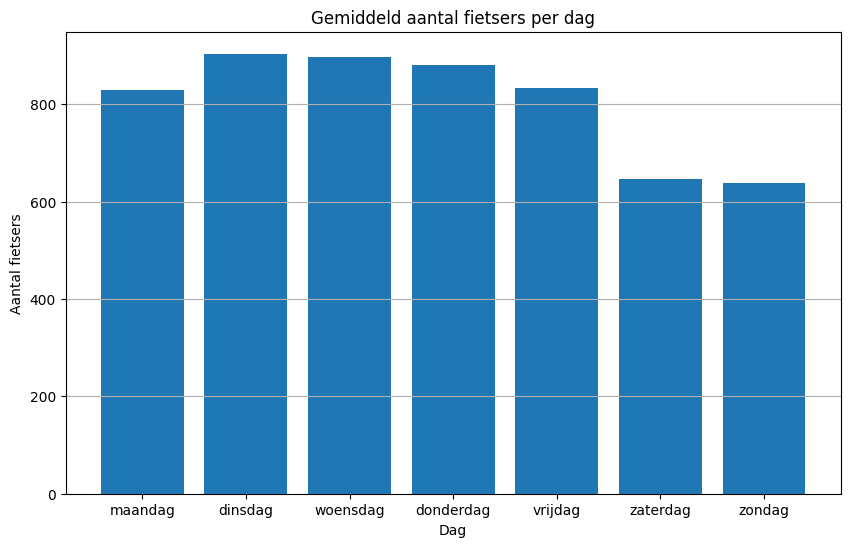

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(x=df['dutchDayNameOfWeek'],height=df['avgBikers'])
plt.grid(axis="y")
plt.title("Gemiddeld aantal fietsers per dag")
plt.xlabel("Dag")
plt.ylabel("Aantal fietsers")
plt.show()

## Reeks 2 - 1

In [ ]:
query = """
SELECT 
    dd.Year, 
    dd.Quarter, 
    SUM(fc.TotalCounts) AS TotalBikers,
    AVG(fc.TotalCounts) AS AverageDailyBikers 
FROM DimDate dd
JOIN FactCountings fc ON fc.DateKey = dd.DateKey
GROUP BY dd.Year, dd.Quarter
ORDER BY dd.Year, dd.Quarter;
"""

* Q1 = Herfst
* Q2 = Lente
* Q3 = Zomer
* Q4 = Winter

In [ ]:
df = getData(engine=engine, query=query)
df

,Year,Quarter,TotalBikers,AverageDailyBikers
0,2020,1,5285721,602
1,2020,2,9727879,1086
2,2020,3,10060246,991
3,2020,4,6378172,624
4,2021,1,5549369,559
5,2021,2,8727481,856
6,2021,3,10362174,936
7,2021,4,7218340,625
8,2022,1,8109086,682
9,2022,2,13308608,939


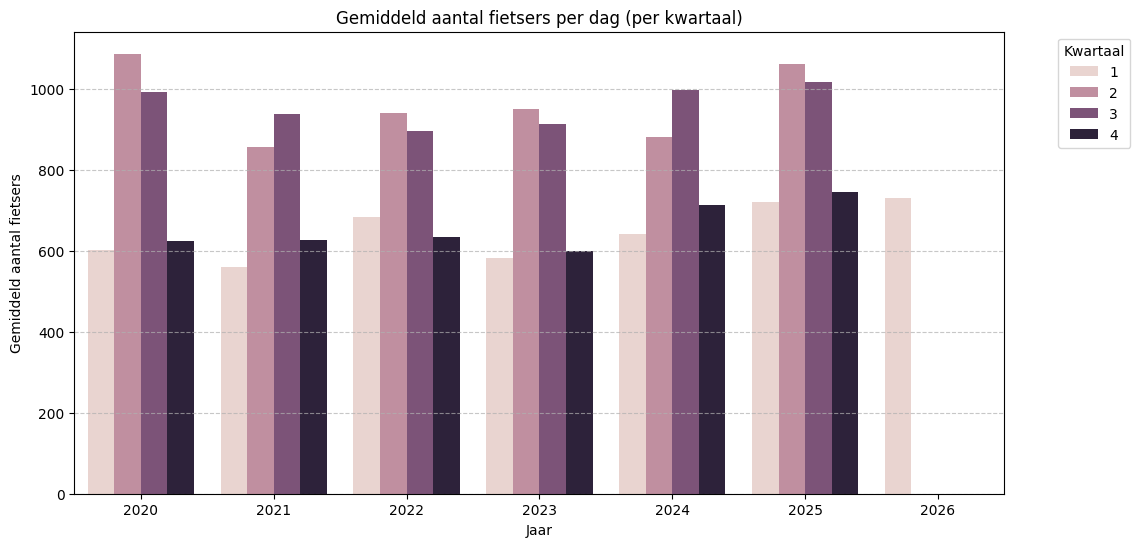

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Year', y='AverageDailyBikers', hue='Quarter')

plt.title('Gemiddeld aantal fietsers per dag (per kwartaal)')
plt.xlabel('Jaar')
plt.ylabel('Gemiddeld aantal fietsers')
plt.legend(title='Kwartaal', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

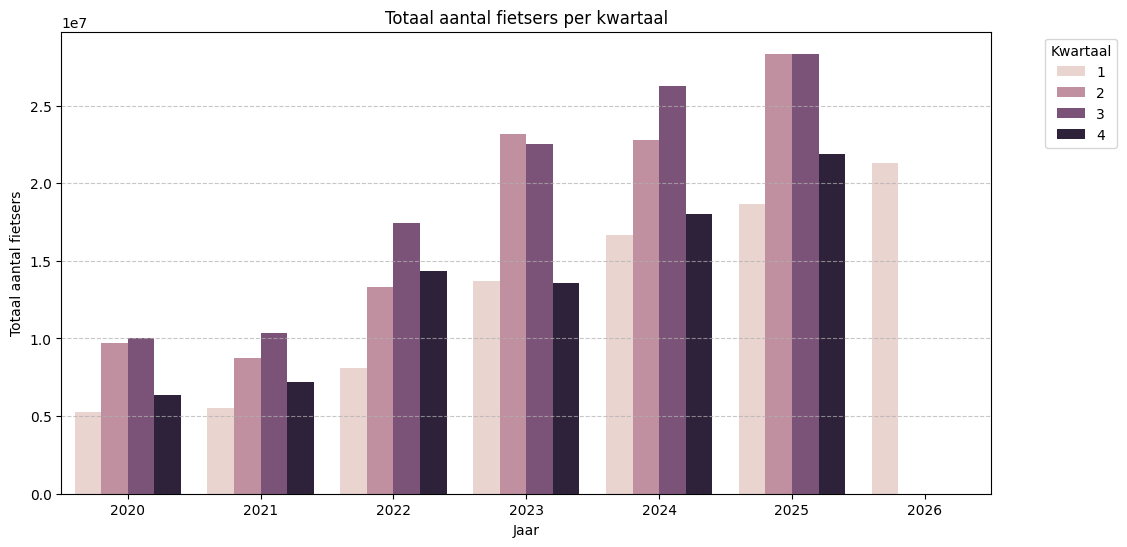

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Year', y='TotalBikers', hue='Quarter')

plt.title('Totaal aantal fietsers per kwartaal')
plt.xlabel('Jaar')
plt.ylabel('Totaal aantal fietsers')
plt.legend(title='Kwartaal', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Maak aparte kolommen voor elk kwartaal (0 of 1)
df_dummies = pd.get_dummies(df, columns=['Quarter'], prefix='Q')

# Bereken nu de correlatie
corr_with_bikers = df_dummies[['AverageDailyBikers', 'Q_1', 'Q_2', 'Q_3', 'Q_4']].corr()

print("Correlatie per Kwartaal:")
print(corr_with_bikers['AverageDailyBikers'][1:])

Correlatie per Kwartaal:
Q_1   -0.572836
Q_2    0.547846
Q_3    0.534395
Q_4   -0.480010
Name: AverageDailyBikers, dtype: float64


In [ ]:
corr_with_bikers = df_dummies[['TotalBikers', 'Q_1', 'Q_2', 'Q_3', 'Q_4']].corr()
print("Correlatie per Kwartaal:")
print(corr_with_bikers['TotalBikers'][1:])


Correlatie per Kwartaal:
Q_1   -0.255973
Q_2    0.158791
Q_3    0.276746
Q_4   -0.166428
Name: TotalBikers, dtype: float64


## reeks 2 - 2

In [3]:
query_factCountings = """SELECT * from FactCountings"""
query_FactMeteo = """SELECT * FROM FactMeteo"""

In [4]:
df_FactCountings = getData(engine=engine, query=query_factCountings)
df_FactMeteo = getData(engine=engine, query=query_FactMeteo)


In [ ]:
df_FactCountings.head(1)

,CountingPointID,DateKey,DirectionInCounts,DirectionOutCounts,TotalCounts
0,100038932,20200101,522,540,1062


In [ ]:
df_FactMeteo.head(1)

,MeteoKey,DateKey,WeatherStationKey,PrecipQuantity,TempAvg,TempMax,TempMin,TempGrassPt100Avg,TempSoilAvg,TempSoilAvg5cm,...,TempSoilAvg20cm,TempSoilAvg50cm,WindSpeed10m,WindSpeedAvg30m,WindGustsSpeed,HumidityRelShelterAvg,Pressure,SunDuration,ShortWaveFromSkyAvg,SunIntAvg
0,2,20260329,6438,2.54,6.75,10.7,0.45,6.97,7.44,7.82,...,7.12,8.37,4.88,NaN,16.23,79.98,1026.14,404.75,147.63,211.33


In [7]:
data = df_FactCountings.merge(right=df_FactMeteo, on="DateKey")

In [ ]:
data = data.groupby('DateKey').agg({
    'TotalCounts': 'sum',
    'TempAvg': 'mean',
    'PrecipQuantity': 'mean',
    'WindSpeed10m': 'mean'
}).reset_index()

In [ ]:
data = data.rename(columns={
    'TotalCounts': 'TotalBikers',
    'TempAvg': 'AvgTemp',
    'PrecipQuantity': 'TotalRain',
    'WindSpeed10m': 'AvgWind'
})

In [10]:
data.head(5)

,DateKey,TotalBikers,AvgTemp,TotalRain,AvgWind
0,20200101,270855,1.576154,0.033077,2.515000
1,20200102,502658,3.560769,0.273846,3.746667
2,20200103,435838,7.476154,5.039231,5.371667
3,20200104,523549,4.853846,0.344615,3.657500
4,20200105,469742,5.645385,0.190769,2.445000


In [11]:
# Een waarde dicht bij 1 is een sterke positieve correlatie
# Een waarde dicht bij -1 is een sterke negatieve correlatie
correlation_matrix = data[['TotalBikers', 'AvgTemp', 'TotalRain', 'AvgWind']].corr()
print("Correlatie Coëfficiënten:")
print(correlation_matrix['TotalBikers'][1:]) # zonder totalbikers zelf te laten zien

Correlatie Coëfficiënten:
AvgTemp      0.331779
TotalRain   -0.191973
AvgWind     -0.238155
Name: TotalBikers, dtype: float64


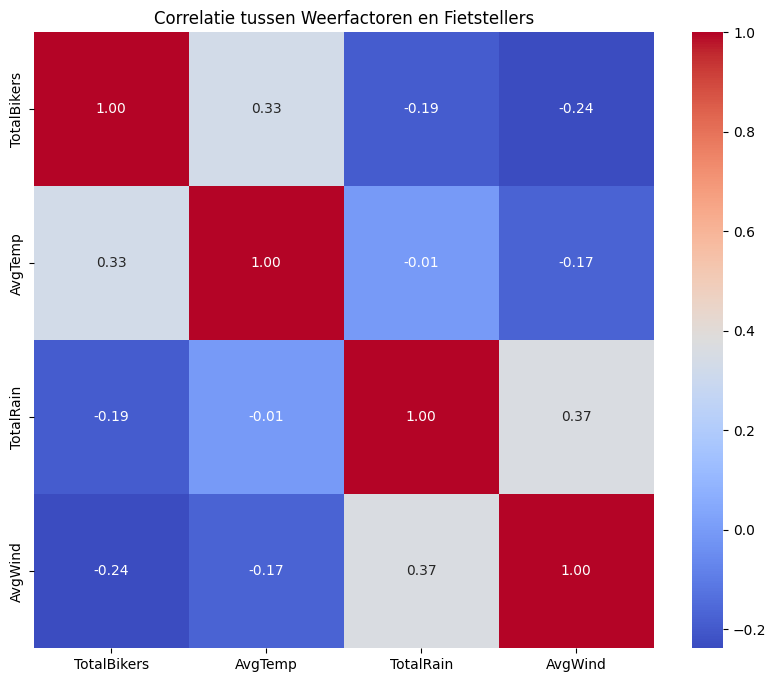

In [12]:
# Visualisatie met een Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlatie tussen Weerfactoren en Fietstellers')
plt.show()

## Conclusie

- **Temperatuur (AvgTemp)** heeft een **matige positieve correlatie (0.33)** met het aantal fietsers.  
  → Wanneer de temperatuur stijgt, neemt het aantal fietsers toe.

- **Neerslag (TotalRain)** heeft een **zwakke negatieve correlatie (-0.19)**.  
  → Meer regen hangt samen met iets minder fietsers, maar beperkt.

- **Windsnelheid (AvgWind)** heeft een **zwakke negatieve correlatie (-0.24)**.  
  → Sterkere wind lijkt het aantal fietsers te verminderen.

### Algemene conclusie
Weersomstandigheden hebben een invloed op het aantal fietsers, waarbij **temperatuur de grootste rol speelt**. Regen en wind hebben ook een negatief effect.

## reeks 3 - 3

In [ ]:
df_fact = getData(engine=engine, query="SELECT * FROM FactCountings")
df_date = getData(engine=engine, query="SELECT * FROM DimDate")

In [ ]:
data = df_fact.merge(df_date, on="DateKey")

In [4]:
df = (data
      .groupby(['Year', 'Quarter'])['TotalCounts']
      .sum()
      .reset_index(name='TotalBikers')
      .sort_values(['Year', 'Quarter']))

In [5]:
# Jaarlijkse totalen berekenen
yearly_df = df.groupby('Year')['TotalBikers'].sum().reset_index()

In [6]:
# Procentuele verandering (YoY % Growth)
yearly_df['Pct_Change'] = yearly_df['TotalBikers'].pct_change() * 100

In [7]:
# Absolute verandering (Hoeveel fietsers kwamen er echt bij?)
yearly_df['Absolute_Change'] = yearly_df['TotalBikers'].diff()

In [8]:
# Cumulatieve Groei (Totaal t.o.v. het allereerste jaar)
first_year_val = yearly_df['TotalBikers'].iloc[0]
yearly_df['Cumulative_Growth_Pct'] = ((yearly_df['TotalBikers'] - first_year_val) / first_year_val) * 100


In [9]:

# Bereken Compound Annual Growth Rate
# Formule: [(Ending Value / Beginning Value)^(1/n)] - 1
n_years = yearly_df['Year'].nunique() - 1
if n_years > 0:
    cagr = ((yearly_df['TotalBikers'].iloc[-1] / yearly_df['TotalBikers'].iloc[0])**(1/n_years) - 1) * 100
else:
    cagr = 0

In [10]:
print(yearly_df.round(2))
print(f"\nDe gemiddelde jaarlijkse groei (CAGR) over de hele periode is: {cagr:.2f}%")

   Year  TotalBikers  Pct_Change  Absolute_Change  Cumulative_Growth_Pct
0  2020     31452018         NaN              NaN                   0.00
1  2021     31857364        1.29         405346.0                   1.29
2  2022     53191696       66.97       21334332.0                  69.12
3  2023     73009347       37.26       19817651.0                 132.13
4  2024     83669167       14.60       10659820.0                 166.02
5  2025     97259865       16.24       13590698.0                 209.23
6  2026     21296672      -78.10      -75963193.0                 -32.29

De gemiddelde jaarlijkse groei (CAGR) over de hele periode is: -6.29%


In [11]:
# Bereken welk percentage van de jaarlijkse fietsers in welk kwartaal rijdt
df['Yearly_Total'] = df.groupby('Year')['TotalBikers'].transform('sum')
df['Quarter_Share'] = (df['TotalBikers'] / df['Yearly_Total']) * 100

In [12]:
# zien of Q4 over de jaren heen groeit tegenover Q2
quarter_trend = df.pivot(index='Year', columns='Quarter', values='Quarter_Share')

In [13]:
print("\nMarktaandeel per Kwartaal (% van jaarvolume):\n")
print(quarter_trend.round(2))


Marktaandeel per Kwartaal (% van jaarvolume):

Quarter       1      2      3      4
Year                                
2020      16.81  30.93  31.99  20.28
2021      17.42  27.40  32.53  22.66
2022      15.25  25.02  32.79  26.94
2023      18.80  31.76  30.84  18.60
2024      19.89  27.21  31.40  21.50
2025      19.20  29.14  29.14  22.52
2026     100.00    NaN    NaN    NaN


#### Visualisatie (gedaan, volledig met AI 🤖)

C:\Users\Luizv\AppData\Local\Temp\ipykernel_26828\972065090.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Absolute_Change', data=yearly_df.dropna(), palette='magma', ax=ax4)


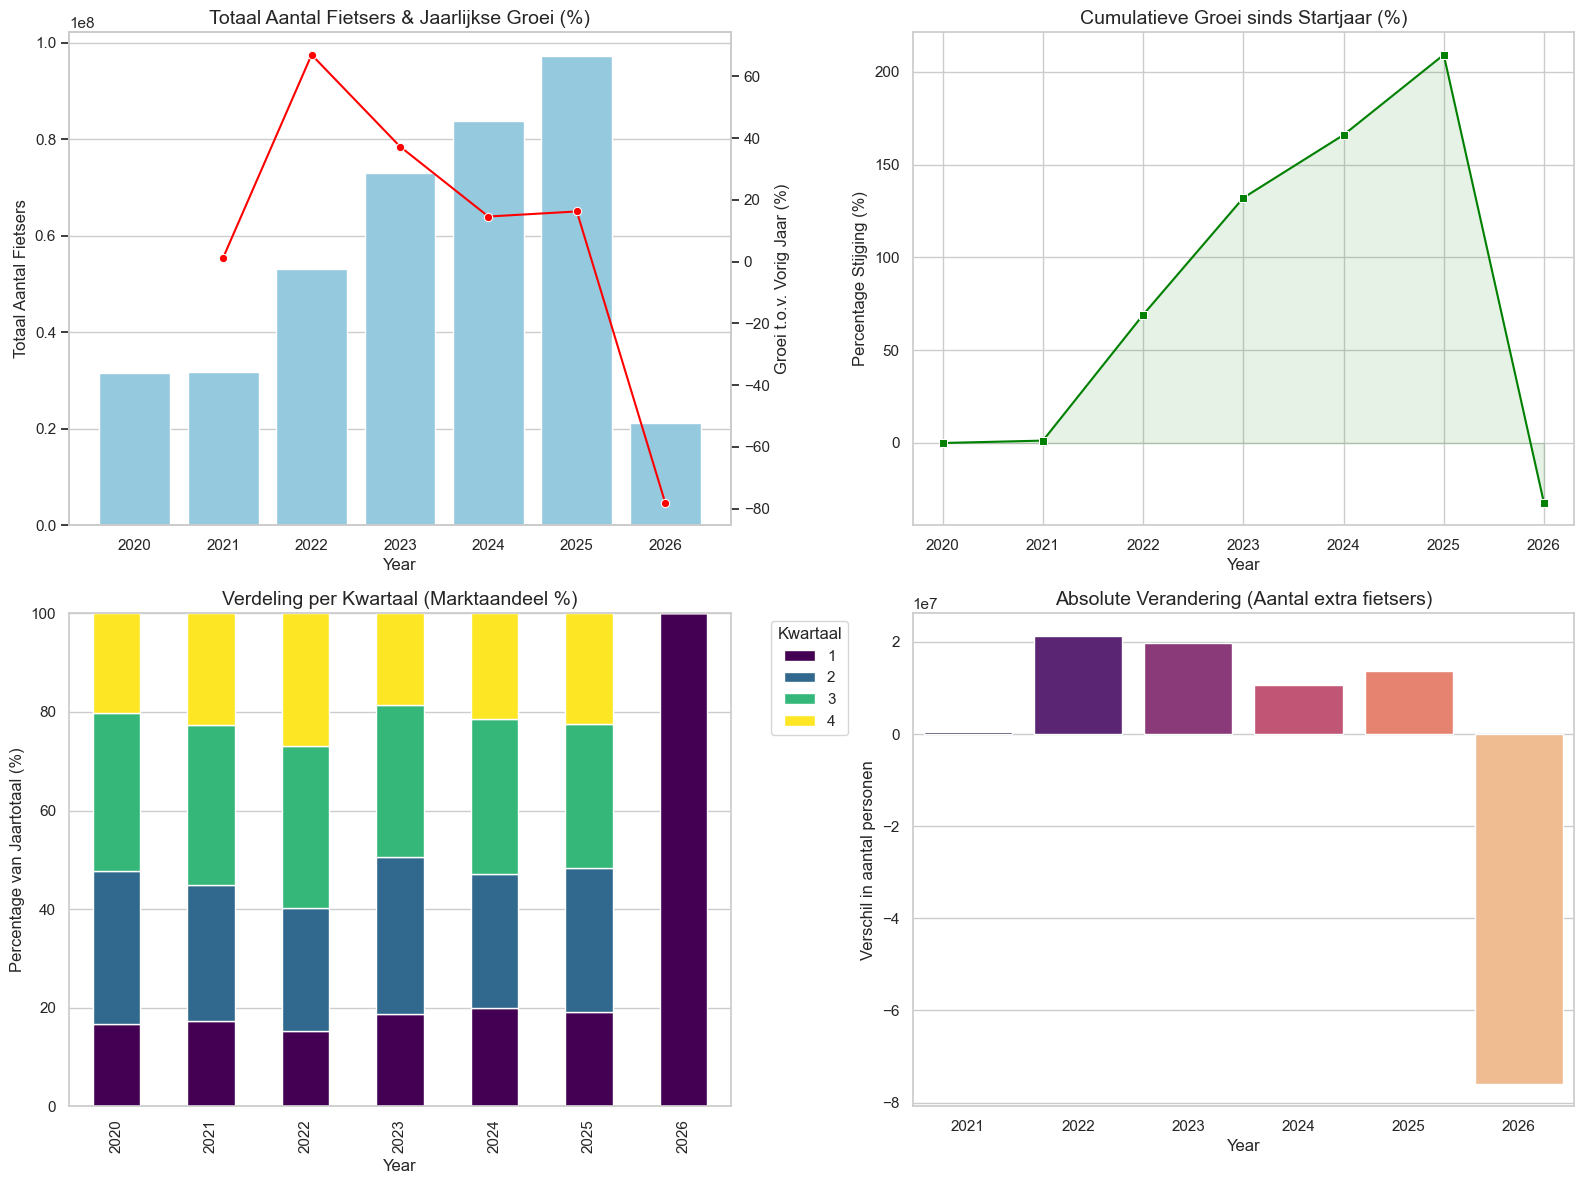

In [14]:
# Stel de stijl in
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# GRAFIEK 1: Absolute Aantallen & YoY Groei %
ax1 = axes[0, 0]
sns.barplot(x='Year', y='TotalBikers', data=yearly_df, color='skyblue', ax=ax1)
ax1_twin = ax1.twinx()
sns.lineplot(x=range(len(yearly_df)), y='Pct_Change', data=yearly_df, marker='o', color='red', ax=ax1_twin)

ax1.set_title('Totaal Aantal Fietsers & Jaarlijkse Groei (%)', fontsize=14)
ax1.set_ylabel('Totaal Aantal Fietsers')
ax1_twin.set_ylabel('Groei t.o.v. Vorig Jaar (%)')
ax1_twin.grid(False)

# GRAFIEK 2: Cumulatieve Groei 
# Hoeveel procent is het totaal gestegen sinds het startjaar?
ax2 = axes[0, 1]
sns.lineplot(x='Year', y='Cumulative_Growth_Pct', data=yearly_df, marker='s', color='green', ax=ax2)
ax2.fill_between(yearly_df['Year'], yearly_df['Cumulative_Growth_Pct'], color='green', alpha=0.1)
ax2.set_title('Cumulatieve Groei sinds Startjaar (%)', fontsize=14)
ax2.set_ylabel('Percentage Stijging (%)')

# GRAFIEK 3: Seizoensverdeling (Quarterly Share) 
# Wordt er verhoudingsgewijs meer gefietst in de winter over de jaren heen?
ax3 = axes[1, 0]
quarter_trend.plot(kind='bar', stacked=True, ax=ax3, colormap='viridis')
ax3.set_title('Verdeling per Kwartaal (Marktaandeel %)', fontsize=14)
ax3.set_ylabel('Percentage van Jaartotaal (%)')
ax3.legend(title='Kwartaal', bbox_to_anchor=(1.05, 1), loc='upper left')

# GRAFIEK 4: Absolute Verschillen (Heatmap of Staaf)
# Hoeveel nieuwe fietsers kwamen er elk jaar bij?
ax4 = axes[1, 1]
sns.barplot(x='Year', y='Absolute_Change', data=yearly_df.dropna(), palette='magma', ax=ax4)
ax4.set_title('Absolute Verandering (Aantal extra fietsers)', fontsize=14)
ax4.set_ylabel('Verschil in aantal personen')

plt.tight_layout()
plt.show()

## Conclusie

**Groei (2020 - 2025)**

* Het totaal aantal fietsers steeg van ongeveer 31 miljoen in 2020 naar bijna 100 miljoen in 2025.

* Het jaar 2022 had de grootste groei van opzichte van de vorige jaren.

* Eind 2025 lag het aantal fietsers ruim 200% hoger dan in het startjaar 2020.

**Seizoensverdeling en Stabiliteit**

De kwartaalverdeling geeft inzicht in het gedrag van de fietsers:

* Tussen 2020 en 2025 bleef de verdeling over de kwartalen relatief stabiel. Dit wijst op een gezonde mix tussen recreatieve fietsers (pieken in Q2 en Q3) en functionele fietsers (woon-werkverkeer dat ook in Q1 en Q4 doorrijdt).

* Hoewel het aantal fietsers enorm steeg, bleef de verhouding tussen de seizoenen vergelijkbaar.


**In alle grafieken zien we een grote daling in 2026:**

- **Verklaring:**  De data voor 2026 is op dit moment (maart 2026) nog onvolledig. Dit verklaart waarom de cumulatieve groei keldert en de absolute verandering negatief kleurt.

- In de verdeling zien we dat voor 2026 enkel Kwartaal 1 (de paarse balk) gevuld is, weer omdat de data nog onvolledig is en we zitten nog maar in Q1.